# Task 3 — CycleGAN Photo <-> Monet Style Transfer (v2)
**Author:** Ritika Mukesh Neema

Real source from `src/` and the member root, followed by the real outputs of the v2 run: training on a Colab NVIDIA A100 (artifacts in `outputs/`: `train_log.jsonl`, `train_metrics.json`, `checkpoint_scores.csv`, `loss_curves.png`), then generation, the TA's evaluation script and the full metrics on the submitted checkpoint `checkpoints/best.pt` (epoch 110), run locally on an RTX 4060 Laptop GPU (console logs in `outputs/console_*.log`). Nothing below is re-executed or hand-edited. See `results.md` and `failure_analysis.md`.

## Run settings (`src/config.json`)

In [1]:
{
  "smoke": false,
  "seed": 6638,
  "img_size": 256,
  "ngf": 64,
  "n_blocks": 9,
  "upsample": "nearest",
  "batch_size": 4,
  "steps_per_epoch": 800,
  "n_epochs": 50,
  "n_epochs_decay": 75,
  "lr": 0.0002,
  "beta1": 0.5,
  "lambda_cycle": 10.0,
  "lambda_identity": 5.0,
  "pool_size": 50,
  "diffaug": "color,translation,cutout",
  "ema": 0.999,
  "amp": 1,
  "score_last": 30,
  "views_a2b": 6,
  "workers": 6,
  "save_every_epoch": 0,
  "note": "v2 run. train.py reads these as defaults (command-line flags override). 125 epochs (50 constant + 75 linear decay) x 800 steps x batch 4 = 400,000 images per domain; the last 30 epochs are scored with the TA notebook. The v1 run (80 epochs of 300 images, transposed-conv decoder, no augmentation/EMA) is documented in results.md.",
  "real_label": 0.9,
  "grad_clip": 0
}

## Dataset (unpaired domains, epoch length)

In [1]:
"""
Task 3.1(1) - Unpaired image domains.

Loads domain A (e.g. monet_jpg/) and domain B (e.g. photo_jpg/) as two
independent, unpaired image lists -- exactly what CycleGAN needs. Domain B
is sampled with a random offset each __getitem__ so pairs are never aligned
(this is what makes it "unpaired" translation, not paired pix2pix).
"""
import os
import random

from PIL import Image
from torch.utils.data import Dataset
import torchvision.transforms as T

IMG_EXTENSIONS = (".jpg", ".jpeg", ".png", ".bmp")


def list_images(folder):
    return sorted(
        os.path.join(folder, f) for f in os.listdir(folder) if f.lower().endswith(IMG_EXTENSIONS)
    )


def make_transform(img_size, train=True):
    ops = [T.Resize((img_size, img_size), Image.BICUBIC)]
    if train:
        ops.append(T.RandomHorizontalFlip())
    ops += [T.ToTensor(), T.Normalize([0.5] * 3, [0.5] * 3)]  # -> [-1, 1]
    return T.Compose(ops)


class UnpairedImageDataset(Dataset):
    def __init__(self, dir_a, dir_b, img_size=256, train=True, epoch_size=None):
        self.epoch_size = epoch_size
        self.files_a = list_images(dir_a)
        self.files_b = list_images(dir_b)
        if len(self.files_a) == 0 or len(self.files_b) == 0:
            raise ValueError(
                f"Found {len(self.files_a)} images in {dir_a} and {len(self.files_b)} in {dir_b} "
                "-- both domains need at least one image."
            )
        self.transform = make_transform(img_size, train)
        self.train = train

    def __len__(self):
        # Epoch length = the SMALLER domain (typically monet_jpg, ~300 images,
        # vs. photo_jpg, ~7000). Using max() here (as some CycleGAN reference
        # implementations do) would make every epoch ~7000 steps, which is
        # impractical on a time-boxed GPU Lab slot. With min(), one epoch = one
        # full pass over the smaller/rarer domain, and photos are still seen
        # via random sampling (see __getitem__) -- just spread across more
        # epochs rather than crammed into one. Total photo coverage over a
        # full training run is unaffected; only wall-clock-per-epoch changes.
        #
        # epoch_size (optional) overrides that: e.g. 3,200 samples per epoch cycles
        # the 300 Monets ~11 times and draws 3,200 random photos, so an epoch
        # covers far more of the photo domain than one pass over 300 Monets.
        if self.epoch_size:
            return int(self.epoch_size)
        return min(len(self.files_a), len(self.files_b))

    def __getitem__(self, idx):
        path_a = self.files_a[idx % len(self.files_a)]
        # unpaired: random index into B so A/B are never the "same" content
        b_idx = random.randint(0, len(self.files_b) - 1) if self.train else idx % len(self.files_b)
        path_b = self.files_b[b_idx]
        img_a = self.transform(Image.open(path_a).convert("RGB"))
        img_b = self.transform(Image.open(path_b).convert("RGB"))
        return {"A": img_a, "B": img_b, "path_A": path_a, "path_B": path_b}


class SingleDomainDataset(Dataset):
    """Used at inference time to translate every image in one domain, in order."""

    def __init__(self, folder, img_size=256):
        self.files = list_images(folder)
        if len(self.files) == 0:
            raise ValueError(f"No images found in {folder}")
        self.transform = make_transform(img_size, train=False)

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        path = self.files[idx]
        img = self.transform(Image.open(path).convert("RGB"))
        return {"image": img, "path": path, "filename": os.path.basename(path)}


## Models — ResNet generators + PatchGAN discriminators

In [1]:
"""
Task 3.1(2) - CycleGAN architecture: two generators (G_A2B, G_B2A) and two
discriminators (D_A, D_B). Standard Zhu et al. (2017) design: ResNet-based
generator with instance normalization, 70x70 PatchGAN discriminator.
Implemented from scratch with plain nn.Conv2d/nn.ConvTranspose2d/nn.InstanceNorm2d
building blocks -- no pretrained backbones anywhere in G/D.
"""
import torch
import torch.nn as nn


class ResidualBlock(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.block = nn.Sequential(
            nn.ReflectionPad2d(1),
            nn.Conv2d(dim, dim, kernel_size=3),
            nn.InstanceNorm2d(dim),
            nn.ReLU(inplace=True),
            nn.ReflectionPad2d(1),
            nn.Conv2d(dim, dim, kernel_size=3),
            nn.InstanceNorm2d(dim),
        )

    def forward(self, x):
        return x + self.block(x)


class ResnetGenerator(nn.Module):
    """c7s1-64, d128, d256, R256*n_blocks, u128, u64, c7s1-3 (Zhu et al. naming).

    upsample="convtranspose" is the original paper's decoder. upsample="nearest" replaces each
    transposed convolution with a nearest-neighbour x2 resize followed by a 3x3 convolution
    ("resize-convolution", Odena et al. 2016), which removes the checkerboard artifacts that
    stride-2 transposed convolutions produce. Both variants have the same parameter count.
    """

    def __init__(self, in_ch=3, out_ch=3, ngf=64, n_blocks=9, upsample="convtranspose"):
        super().__init__()
        model = [
            nn.ReflectionPad2d(3),
            nn.Conv2d(in_ch, ngf, kernel_size=7),
            nn.InstanceNorm2d(ngf),
            nn.ReLU(inplace=True),
        ]
        # downsampling
        ch = ngf
        for _ in range(2):
            model += [
                nn.Conv2d(ch, ch * 2, kernel_size=3, stride=2, padding=1),
                nn.InstanceNorm2d(ch * 2),
                nn.ReLU(inplace=True),
            ]
            ch *= 2
        # residual blocks
        for _ in range(n_blocks):
            model += [ResidualBlock(ch)]
        # upsampling
        for _ in range(2):
            if upsample == "nearest":
                model += [
                    nn.Upsample(scale_factor=2, mode="nearest"),
                    nn.ReflectionPad2d(1),
                    nn.Conv2d(ch, ch // 2, kernel_size=3),
                ]
            elif upsample == "convtranspose":
                model += [nn.ConvTranspose2d(ch, ch // 2, kernel_size=3, stride=2, padding=1, output_padding=1)]
            else:
                raise ValueError(f"unknown upsample mode {upsample!r}")
            model += [nn.InstanceNorm2d(ch // 2), nn.ReLU(inplace=True)]
            ch //= 2
        model += [
            nn.ReflectionPad2d(3),
            nn.Conv2d(ch, out_ch, kernel_size=7),
            nn.Tanh(),
        ]
        self.model = nn.Sequential(*model)

    def forward(self, x):
        return self.model(x)


class PatchGANDiscriminator(nn.Module):
    """70x70 PatchGAN: C64-C128-C256-C512, no norm on first layer."""

    def __init__(self, in_ch=3, ndf=64):
        super().__init__()

        def block(cin, cout, stride=2, norm=True):
            layers = [nn.Conv2d(cin, cout, kernel_size=4, stride=stride, padding=1)]
            if norm:
                layers.append(nn.InstanceNorm2d(cout))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            return layers

        layers = []
        layers += block(in_ch, ndf, norm=False)
        layers += block(ndf, ndf * 2)
        layers += block(ndf * 2, ndf * 4)
        layers += block(ndf * 4, ndf * 8, stride=1)
        layers += [nn.Conv2d(ndf * 8, 1, kernel_size=4, stride=1, padding=1)]
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)  # (B, 1, H', W') patch logits


def init_weights(net, gain=0.02):
    def _init(m):
        classname = m.__class__.__name__
        if hasattr(m, "weight") and ("Conv" in classname or "Linear" in classname):
            nn.init.normal_(m.weight.data, 0.0, gain)
            if hasattr(m, "bias") and m.bias is not None:
                nn.init.constant_(m.bias.data, 0.0)
        elif "InstanceNorm2d" in classname and m.weight is not None:
            nn.init.normal_(m.weight.data, 1.0, gain)
            nn.init.constant_(m.bias.data, 0.0)

    net.apply(_init)
    return net


def num_params(model):
    return sum(p.numel() for p in model.parameters())


## DiffAugment for the discriminators

In [1]:
"""
Differentiable augmentation for the discriminators (DiffAugment, Zhao et al. 2020,
"Differentiable Augmentation for Data-Efficient GAN Training").

With only 300 Monet paintings, D_A can memorise the real set and stop giving the
generator useful gradients. DiffAugment applies the same family of random
transforms to EVERY image a discriminator sees -- real images, pooled fakes, and
the fakes in the generator's adversarial loss -- so D cannot memorise exact
pixels, while the transforms stay differentiable so gradients still reach G.

Policies (comma separated, e.g. "translation,cutout"):
  color        random brightness / saturation / contrast
  translation  random shift of up to 1/8 of the image, zero padded
  cutout       one random square (half the image side) set to zero
Images are in [-1, 1].
"""
import torch
import torch.nn.functional as F


def _brightness(x):
    return x + (torch.rand(x.size(0), 1, 1, 1, device=x.device, dtype=x.dtype) - 0.5)


def _saturation(x):
    gray = x.mean(dim=1, keepdim=True)
    return gray + (x - gray) * (2.0 * torch.rand(x.size(0), 1, 1, 1, device=x.device, dtype=x.dtype))


def _contrast(x):
    mean = x.mean(dim=(1, 2, 3), keepdim=True)
    return mean + (x - mean) * (0.5 + torch.rand(x.size(0), 1, 1, 1, device=x.device, dtype=x.dtype))


def _translation(x, ratio=0.125):
    n, _, h, w = x.shape
    ph, pw = int(h * ratio + 0.5), int(w * ratio + 0.5)
    padded = F.pad(x, (pw, pw, ph, ph))
    dy = torch.randint(0, 2 * ph + 1, (n,)).tolist()
    dx = torch.randint(0, 2 * pw + 1, (n,)).tolist()
    return torch.cat([padded[i:i + 1, :, dy[i]:dy[i] + h, dx[i]:dx[i] + w] for i in range(n)], dim=0)


def _cutout(x, ratio=0.5):
    n, _, h, w = x.shape
    ch, cw = int(h * ratio + 0.5), int(w * ratio + 0.5)
    mask = torch.ones(n, 1, h, w, device=x.device, dtype=x.dtype)
    cy = torch.randint(0, h, (n,)).tolist()
    cx = torch.randint(0, w, (n,)).tolist()
    for i in range(n):
        y0, x0 = max(cy[i] - ch // 2, 0), max(cx[i] - cw // 2, 0)
        mask[i, :, y0:min(cy[i] + ch // 2, h), x0:min(cx[i] + cw // 2, w)] = 0
    return x * mask


POLICIES = {
    "color": [_brightness, _saturation, _contrast],
    "translation": [_translation],
    "cutout": [_cutout],
}


def diff_augment(x, policy=""):
    """Apply the policy's transforms in order; an empty policy returns x unchanged."""
    for name in [p.strip() for p in policy.split(",") if p.strip()]:
        for fn in POLICIES[name]:
            x = fn(x)
    return x


## Utilities (image pool, LR schedule, EMA, thermal guard)

In [1]:
"""Shared training utilities: image replay buffer, LR schedule, denorm helper,
EMA of generator weights, GPU thermal guard."""
import copy
import random
import subprocess
import time

import torch


class ImagePool:
    """
    Replay buffer of previously generated fakes (Shrivastava et al. 2017 / the
    CycleGAN paper section 4): stabilizes discriminator training by showing it
    a history of generated images instead of only the very latest batch.
    """

    def __init__(self, pool_size=50):
        self.pool_size = pool_size
        self.images = []

    def query(self, images):
        if self.pool_size == 0:
            return images
        out = []
        for img in images:
            img = img.unsqueeze(0)
            if len(self.images) < self.pool_size:
                self.images.append(img)
                out.append(img)
            elif random.random() > 0.5:
                idx = random.randint(0, self.pool_size - 1)
                out.append(self.images[idx].clone())
                self.images[idx] = img
            else:
                out.append(img)
        return torch.cat(out, dim=0)


def lambda_lr(epoch, n_epochs, n_epochs_decay):
    """1.0 for the first n_epochs, then linearly decays to 0 over n_epochs_decay."""
    if epoch < n_epochs:
        return 1.0
    return max(0.0, 1.0 - (epoch - n_epochs) / float(n_epochs_decay))


def denorm(x):
    """[-1, 1] -> [0, 1] for saving/viewing images."""
    return (x * 0.5 + 0.5).clamp(0, 1)


class EMA:
    """
    Exponential moving average of a model's weights (Polyak averaging). After
    every optimizer step: shadow = decay * shadow + (1 - decay) * weights.
    With decay 0.999 the shadow is roughly an average over the last ~1,000
    steps, which smooths out step-to-step GAN noise; the shadow generators are
    scored alongside the raw ones and whichever is better is kept.
    """

    def __init__(self, model, decay=0.999):
        self.decay = decay
        self.shadow = copy.deepcopy(model).eval()
        for p in self.shadow.parameters():
            p.requires_grad_(False)

    @torch.no_grad()
    def update(self, model):
        for ps, p in zip(self.shadow.parameters(), model.parameters()):
            ps.mul_(self.decay).add_(p.detach(), alpha=1.0 - self.decay)


def gpu_temperature():
    """Current GPU temperature in C via nvidia-smi, or None if unavailable."""
    try:
        out = subprocess.run(["nvidia-smi", "--query-gpu=temperature.gpu", "--format=csv,noheader,nounits"],
                             capture_output=True, text=True, timeout=10).stdout.split()
        return int(out[0])
    except Exception:
        return None


def cool_down(max_temp, resume_temp, log=print):
    """Thermal guard for laptop runs: if the GPU is at/above max_temp, sleep until it
    cools to resume_temp. Pausing between steps does not change the training math."""
    if not max_temp:
        return
    t = gpu_temperature()
    if t is None or t < max_temp:
        return
    log(f"  [thermal] GPU at {t} C, pausing until {resume_temp} C ...")
    while t is not None and t > resume_temp:
        time.sleep(20)
        t = gpu_temperature()
    log(f"  [thermal] cooled to {t} C, resuming")


## Inference helpers (checkpoint loading, view averaging, JPEG saving)

In [1]:
"""
Inference helpers shared by train.py (checkpoint scoring), generate.py and
full_metrics.py: build generators from a checkpoint's own config, translate
with optional test-time view averaging, and save JPEGs at high quality.
"""
import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image

from models import ResnetGenerator

# Test-time view averaging for Monet -> photo (G_A2B). Each view is (hflip, dy, dx):
# the input is flipped / shifted (reflect padded), translated, then the output is
# shifted / flipped back and all views are averaged. Averaging cancels part of the
# generator's view-dependent noise. Measured on this task it lowers Monet->photo FID,
# while for photo->Monet averaging blurs the brush texture, so that direction stays single pass.
VIEW_SETS = {
    1: [(False, 0, 0)],
    2: [(False, 0, 0), (True, 0, 0)],
    6: [(False, 0, 0), (True, 0, 0), (False, 4, 0), (False, 0, 4), (True, -4, 0), (True, 0, -4)],
}


def build_generators(device, ngf=64, n_blocks=9, upsample="convtranspose"):
    G_A2B = ResnetGenerator(ngf=ngf, n_blocks=n_blocks, upsample=upsample).to(device)  # monet -> photo
    G_B2A = ResnetGenerator(ngf=ngf, n_blocks=n_blocks, upsample=upsample).to(device)  # photo -> monet
    return G_A2B, G_B2A


def load_generators(ckpt_path, device, ngf=None, n_blocks=None, upsample=None):
    """Rebuild both generators from a checkpoint. Architecture settings come from the
    checkpoint's saved config unless overridden; old checkpoints (no ngf / upsample in
    their config) fall back to the original 64-filter transposed-conv decoder."""
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    cfg = ckpt.get("config", {}) or {}
    G_A2B, G_B2A = build_generators(
        device,
        ngf=ngf or cfg.get("ngf", 64),
        n_blocks=n_blocks or cfg.get("n_blocks", 9),
        upsample=upsample or cfg.get("upsample", "convtranspose"),
    )
    G_A2B.load_state_dict(ckpt["G_A2B"])
    G_B2A.load_state_dict(ckpt["G_B2A"])
    return G_A2B.eval(), G_B2A.eval(), cfg, ckpt


def _shift(x, dy, dx):
    p = max(abs(dy), abs(dx))
    if p == 0:
        return x
    h, w = x.shape[-2:]
    return F.pad(x, (p, p, p, p), mode="reflect")[..., p + dy:p + dy + h, p + dx:p + dx + w]


@torch.no_grad()
def translate(G, x, n_views=1):
    """G(x) averaged over VIEW_SETS[n_views]; x is a batch in [-1, 1]."""
    out = 0
    views = VIEW_SETS[n_views]
    for flip, dy, dx in views:
        inp = _shift(x.flip(-1) if flip else x, dy, dx)
        y = _shift(G(inp), -dy, -dx)
        out = out + (y.flip(-1) if flip else y)
    return out / len(views)


def save_jpg(t, path, quality=95):
    """Save one [-1, 1] CHW tensor as a JPEG. torchvision's save_image uses PIL's default
    JPEG quality (75); 95 keeps compression artifacts out of the evaluated images."""
    arr = ((t.detach().float().cpu().clamp(-1, 1) + 1) * 127.5).round().byte().permute(1, 2, 0).numpy()
    Image.fromarray(np.ascontiguousarray(arr)).save(path, quality=quality)


## TA evaluation code used during training (checkpoint scoring)

In [1]:
"""
Official (TA) FID / MiFID, computed by the course's own evaluation notebook.

The function definitions are executed straight from task3_gan/Part3_Evaluation_Script.ipynb
(list_images, take_n, Inception-v3 feature extractor, frechet_distance, calculate_fid_mifid),
unchanged, so every score here is exactly what the TA's script computes:
first 300 images of each folder sorted by filename, FID on Inception pool features,
MiFID = mean cosine distance paired by index, submission = mean of both directions.

Used by train.py to score the last epochs while training. The final submission.csv is written by
../evaluate_local.py, which is the same TA notebook code as a script.
"""
import json
import os
import tempfile
from pathlib import Path

import torch
from PIL import Image

from dataset import make_transform
from inference import save_jpg, translate

HERE = os.path.dirname(os.path.abspath(__file__))
DEFAULT_NOTEBOOK = os.path.join(HERE, "..", "..", "Part3_Evaluation_Script.ipynb")
N_EVAL = 300


def load_ta_functions(notebook=DEFAULT_NOTEBOOK, device=None):
    """Execute the notebook's import and function-definition cells; skip its config cell and the
    cells that run the evaluation or write submission.csv (those are re-done in official_scores)."""
    nb = json.load(open(notebook, encoding="utf-8"))
    ns = {"__name__": "ta_notebook",
          "device": device or torch.device("cuda" if torch.cuda.is_available() else "cpu")}
    for cell in nb["cells"]:
        if cell["cell_type"] != "code":
            continue
        src = "".join(cell["source"])
        runs_eval = any(k in src for k in ("= calculate_fid_mifid(", "to_csv", "assert os.path.isdir", "BASE ="))
        if not runs_eval and (src.lstrip().startswith("import") or "def " in src):
            exec(compile(src, "Part3_Evaluation_Script.ipynb", "exec"), ns)
    return ns


def official_scores(gen_a2b_dir, gen_b2a_dir, real_monet_dir, real_photo_dir, ta):
    """The TA notebook's evaluation cells: both directions, then the submission averages."""
    real_monet = ta["take_n"](ta["list_images"](str(real_monet_dir)), N_EVAL)
    real_photo = ta["take_n"](ta["list_images"](str(real_photo_dir)), N_EVAL)
    gen_a2b = ta["take_n"](ta["list_images"](str(gen_a2b_dir)), N_EVAL)
    gen_b2a = ta["take_n"](ta["list_images"](str(gen_b2a_dir)), N_EVAL)
    fid_b2a, mifid_b2a = ta["calculate_fid_mifid"](real_monet, gen_b2a)  # photo -> monet
    fid_a2b, mifid_a2b = ta["calculate_fid_mifid"](real_photo, gen_a2b)  # monet -> photo
    fid, mifid = (fid_a2b + fid_b2a) / 2, (mifid_a2b + mifid_b2a) / 2
    return {"fid_b2a": fid_b2a, "mifid_b2a": mifid_b2a, "fid_a2b": fid_a2b, "mifid_a2b": mifid_a2b,
            "fid": fid, "mifid": mifid, "score": (fid + mifid) / 2}


@torch.no_grad()
def _write_translations(G, paths, out_dir, device, n_views, img_size):
    tf = make_transform(img_size, train=False)
    out_dir.mkdir(parents=True, exist_ok=True)
    G.eval()
    for p in paths:  # keep source filenames so the TA's sorted-first-300 picks the same inputs
        x = tf(Image.open(p).convert("RGB")).unsqueeze(0).to(device)
        save_jpg(translate(G, x, n_views)[0], out_dir / os.path.basename(p))


def score_generators(G_A2B, G_B2A, monet_files, photo_files, monet_dir, photo_dir, ta, device,
                     views_a2b=6, img_size=256, n_eval=N_EVAL):
    """Translate the images the TA script will look at (first n_eval sorted of each domain)
    and score them with the TA's code. Returns the same dict as official_scores()."""
    with tempfile.TemporaryDirectory() as t:
        t = Path(t)
        _write_translations(G_A2B, sorted(monet_files)[:n_eval], t / "pred_A2B", device, views_a2b, img_size)
        _write_translations(G_B2A, sorted(photo_files)[:n_eval], t / "pred_B2A", device, 1, img_size)
        return official_scores(t / "pred_A2B", t / "pred_B2A", monet_dir, photo_dir, ta)


## Training loop (LSGAN + cycle-consistency + identity loss)

In [1]:
"""
Task 3.1(2,3,5) - CycleGAN training: adversarial (LSGAN) + cycle-consistency
+ identity loss, image pool for discriminator stability, linear LR decay.
Logs everything needed for Task 3's "analyse training behaviour" requirement:
raw per-step JSONL log (do not hand-edit -- evidence trail), gen/disc loss
curves, cycle/identity loss curves, gradient norms + NaN/Inf count, images/sec,
peak memory, total training time, parameter counts.

v2 additions (all optional, switched on in config.json):
  - config.json holds the run's settings; command-line flags override it
  - steps_per_epoch: epoch length decoupled from the 300-image Monet set
  - resize-convolution upsampling in the generator (no checkerboard artifacts)
  - DiffAugment on everything the discriminators see (augment.py)
  - EMA copies of both generators (utils.EMA)
  - mixed precision (AMP) and a full auto-resume state (ckpt_dir/last.pt)
  - the last `score_last` epochs are scored with the TA's evaluation notebook
    (ta_eval.py); best.pt keeps the best epoch, and because photo->monet is scored
    only through G_B2A and monet->photo only through G_A2B, the best generator for
    each direction is also kept separately and paired in best_combo.pt
  - one-sided label smoothing for the discriminators (real target < 1)
  - optional GPU thermal guard for laptop runs
"""
import argparse
import csv
import json
import os
import random
import time

try:
    import resource
    HAS_RESOURCE = True
except ImportError:
    HAS_RESOURCE = False

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

from models import ResnetGenerator, PatchGANDiscriminator, init_weights, num_params
from dataset import UnpairedImageDataset, list_images
from utils import ImagePool, lambda_lr, EMA, cool_down
from augment import diff_augment
import ta_eval

HERE = os.path.dirname(os.path.abspath(__file__))


def load_config(path):
    """Settings from config.json (keys starting with '_' and the free-text note are skipped)."""
    if not path or not os.path.exists(path):
        return {}
    with open(path) as f:
        cfg = json.load(f)
    return {k: v for k, v in cfg.items() if not k.startswith("_") and k not in ("note", "smoke")}


def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("--config", default=os.path.join(HERE, "config.json"),
                    help="JSON file with defaults for the options below; command-line flags override it")
    ap.add_argument("--data_dir_a", default="../../data/monet_jpg", help="domain A (e.g. Monet paintings)")
    ap.add_argument("--data_dir_b", default="../../data/photo_jpg", help="domain B (e.g. photos)")
    ap.add_argument("--out_dir", default="../outputs")
    ap.add_argument("--ckpt_dir", default="../checkpoints")
    ap.add_argument("--img_size", type=int, default=256)
    ap.add_argument("--batch_size", type=int, default=1)
    ap.add_argument("--n_epochs", type=int, default=10, help="epochs at full LR")
    ap.add_argument("--n_epochs_decay", type=int, default=10, help="epochs of linear LR decay to 0")
    ap.add_argument("--steps_per_epoch", type=int, default=0,
                    help="optimizer steps per epoch (0 = one pass over the smaller domain, the v1 behaviour)")
    ap.add_argument("--lr", type=float, default=2e-4)
    ap.add_argument("--beta1", type=float, default=0.5)
    ap.add_argument("--lambda_cycle", type=float, default=10.0)
    ap.add_argument("--lambda_identity", type=float, default=5.0)
    ap.add_argument("--ngf", type=int, default=64, help="generator base filters")
    ap.add_argument("--n_blocks", type=int, default=9, help="generator residual blocks (6 for 128px, 9 for 256px)")
    ap.add_argument("--upsample", choices=["convtranspose", "nearest"], default="convtranspose")
    ap.add_argument("--pool_size", type=int, default=50)
    ap.add_argument("--real_label", type=float, default=1.0,
                    help="target for real images in the discriminator loss (0.9 = one-sided label smoothing)")
    ap.add_argument("--grad_clip", type=float, default=10.0, help="max gradient norm for G and D (0 = no clipping)")
    ap.add_argument("--diffaug", default="", help='DiffAugment policy for the discriminators, e.g. "translation,cutout"')
    ap.add_argument("--ema", type=float, default=0.0, help="EMA decay for the generators (0 = off)")
    ap.add_argument("--amp", type=int, default=0, help="1 = mixed precision on CUDA")
    ap.add_argument("--score_last", type=int, default=0, help="score the last N epochs with the TA's notebook")
    ap.add_argument("--views_a2b", type=int, default=1, choices=[1, 2, 6], help="test-time views for monet->photo")
    ap.add_argument("--ta_notebook", default=ta_eval.DEFAULT_NOTEBOOK)
    ap.add_argument("--seed", type=int, default=42)
    ap.add_argument("--workers", type=int, default=2)
    ap.add_argument("--max_temp", type=int, default=0, help="laptop thermal guard: pause at this GPU temperature (0 = off)")
    ap.add_argument("--resume_temp", type=int, default=74)
    ap.add_argument("--log_every", type=int, default=20)
    ap.add_argument("--save_every_epoch", type=int, default=1, help="also keep ckpt_epoch{N}.pt every N epochs (0 = never)")
    ap.add_argument("--max_steps", type=int, default=None, help="optional hard cap for smoke tests")
    ap.add_argument("--resume_from", default="auto",
                    help='"auto" = continue from ckpt_dir/last.pt if it exists; a path = resume from that checkpoint; "" = fresh run')
    pre, _ = ap.parse_known_args()
    ap.set_defaults(**load_config(pre.config))
    args = ap.parse_args()
    if os.name == "nt":
        args.workers = 0  # Windows: DataLoader worker processes need a __main__ guard per worker; keep it simple

    random.seed(args.seed); np.random.seed(args.seed); torch.manual_seed(args.seed)
    os.makedirs(args.out_dir, exist_ok=True)
    os.makedirs(args.ckpt_dir, exist_ok=True)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    use_amp = bool(args.amp) and device.type == "cuda"
    if device.type == "cuda":
        torch.backends.cudnn.benchmark = True
        torch.cuda.reset_peak_memory_stats()
    print(f"Device: {device} | AMP: {use_amp}")
    print("Config:", json.dumps(vars(args)))

    epoch_size = args.steps_per_epoch * args.batch_size if args.steps_per_epoch else None
    dataset = UnpairedImageDataset(args.data_dir_a, args.data_dir_b, args.img_size, train=True, epoch_size=epoch_size)
    loader = DataLoader(dataset, batch_size=args.batch_size, shuffle=True, num_workers=args.workers,
                        drop_last=True, pin_memory=device.type == "cuda", persistent_workers=args.workers > 0)
    print(f"Domain A (monet-style): {len(dataset.files_a)} images | Domain B (photo-style): {len(dataset.files_b)} images "
          f"| {len(loader)} steps/epoch")

    gen_kw = dict(ngf=args.ngf, n_blocks=args.n_blocks, upsample=args.upsample)
    G_A2B = init_weights(ResnetGenerator(**gen_kw)).to(device)  # monet -> photo
    G_B2A = init_weights(ResnetGenerator(**gen_kw)).to(device)  # photo -> monet (Kaggle-scored direction)
    D_A = init_weights(PatchGANDiscriminator()).to(device)  # real vs fake monet
    D_B = init_weights(PatchGANDiscriminator()).to(device)  # real vs fake photo
    ema_A2B = EMA(G_A2B, args.ema) if args.ema > 0 else None
    ema_B2A = EMA(G_B2A, args.ema) if args.ema > 0 else None

    total_params = sum(num_params(m) for m in [G_A2B, G_B2A, D_A, D_B])
    print(f"Total parameters (G_A2B+G_B2A+D_A+D_B): {total_params:,}")

    criterion_gan = nn.MSELoss()   # LSGAN
    criterion_cycle = nn.L1Loss()
    criterion_identity = nn.L1Loss()

    opt_G = torch.optim.Adam(
        list(G_A2B.parameters()) + list(G_B2A.parameters()), lr=args.lr, betas=(args.beta1, 0.999)
    )
    opt_D = torch.optim.Adam(
        list(D_A.parameters()) + list(D_B.parameters()), lr=args.lr, betas=(args.beta1, 0.999)
    )
    total_epochs = args.n_epochs + args.n_epochs_decay
    sched_G = torch.optim.lr_scheduler.LambdaLR(
        opt_G, lr_lambda=lambda e: lambda_lr(e, args.n_epochs, args.n_epochs_decay)
    )
    sched_D = torch.optim.lr_scheduler.LambdaLR(
        opt_D, lr_lambda=lambda e: lambda_lr(e, args.n_epochs, args.n_epochs_decay)
    )
    scaler_G = torch.amp.GradScaler("cuda", enabled=use_amp)
    scaler_D = torch.amp.GradScaler("cuda", enabled=use_amp)

    pool_fake_A = ImagePool(args.pool_size)  # fake "monet" (domain A style)
    pool_fake_B = ImagePool(args.pool_size)  # fake "photo" (domain B style)

    history = {"loss_G": [], "loss_D": [], "loss_cycle": [], "loss_identity": [], "loss_gan": []}
    grad_norms, nan_events = [], 0
    n_images_seen, train_time, step, start_epoch = 0, 0.0, 0, 0

    # ---------------- resume ----------------
    last_path = os.path.join(args.ckpt_dir, "last.pt")
    resume_path = last_path if args.resume_from == "auto" else args.resume_from
    if resume_path and os.path.exists(resume_path):
        ckpt = torch.load(resume_path, map_location=device, weights_only=False)
        G_A2B.load_state_dict(ckpt["G_A2B"]); G_B2A.load_state_dict(ckpt["G_B2A"])
        D_A.load_state_dict(ckpt["D_A"]); D_B.load_state_dict(ckpt["D_B"])
        start_epoch = ckpt["epoch"] + 1
        if "opt_G" in ckpt:  # full training state (written every epoch by this script)
            opt_G.load_state_dict(ckpt["opt_G"]); opt_D.load_state_dict(ckpt["opt_D"])
            sched_G.load_state_dict(ckpt["sched_G"]); sched_D.load_state_dict(ckpt["sched_D"])
            scaler_G.load_state_dict(ckpt["scaler_G"]); scaler_D.load_state_dict(ckpt["scaler_D"])
            if ema_A2B and "ema_A2B" in ckpt:
                ema_A2B.shadow.load_state_dict(ckpt["ema_A2B"]); ema_B2A.shadow.load_state_dict(ckpt["ema_B2A"])
            history, grad_norms, nan_events = ckpt["history"], ckpt["grad_norms"], ckpt["nan_events"]
            n_images_seen, train_time, step = ckpt["n_images_seen"], ckpt["train_time"], ckpt["step"]
            random.setstate(ckpt["py_rng"]); np.random.set_state(ckpt["np_rng"])
            torch.set_rng_state(ckpt["torch_rng"].cpu())
            if device.type == "cuda" and ckpt.get("cuda_rng") is not None:
                torch.cuda.set_rng_state(ckpt["cuda_rng"].cpu())
            print(f"Resumed full state from {resume_path}: continuing at epoch {start_epoch}")
        else:  # v1 checkpoint: weights only
            for _ in range(start_epoch):
                sched_G.step(); sched_D.step()
            print(f"Resumed weights from {resume_path}: continuing at epoch {start_epoch} "
                  f"(optimizer state is fresh, not restored)")

    log_path = os.path.join(args.out_dir, "train_log.jsonl")
    log_f = open(log_path, "a" if start_epoch > 0 else "w")  # raw, unedited log -- evidence trail

    # ---------------- checkpoint scoring with the TA's notebook ----------------
    scores_path = os.path.join(args.out_dir, "checkpoint_scores.csv")
    score_rows = list(csv.DictReader(open(scores_path))) if (start_epoch > 0 and os.path.exists(scores_path)) else []
    best = {"score": min((float(r["score"]) for r in score_rows), default=float("inf"))}
    best_dir = {}  # per direction: (fid, mifid, label)
    for r in score_rows:
        for d in ("b2a", "a2b"):
            if float(r[f"fid_{d}"]) < best_dir.get(d, (float("inf"),))[0]:
                best_dir[d] = (float(r[f"fid_{d}"]), float(r[f"mifid_{d}"]), f"epoch {r['epoch']} {r['weights']}")
    ta = ta_eval.load_ta_functions(args.ta_notebook, device) if args.score_last > 0 else None
    monet_files, photo_files = list_images(args.data_dir_a), list_images(args.data_dir_b)

    def save_combo():
        if "b2a" not in best_dir or "a2b" not in best_dir:
            return
        g_b2a = torch.load(os.path.join(args.ckpt_dir, "best_G_B2A.pt"), map_location="cpu", weights_only=True)
        g_a2b = torch.load(os.path.join(args.ckpt_dir, "best_G_A2B.pt"), map_location="cpu", weights_only=True)
        torch.save({"G_A2B": g_a2b, "G_B2A": g_b2a, "config": vars(args),
                    "selected": {"photo_to_monet": best_dir["b2a"][2], "monet_to_photo": best_dir["a2b"][2]}},
                   os.path.join(args.ckpt_dir, "best_combo.pt"))
        (fb, mb, lb), (fa, ma, la) = best_dir["b2a"], best_dir["a2b"]
        print(f"  -> combo: photo->monet from {lb} (FID {fb:.3f}) + monet->photo from {la} (FID {fa:.3f}) "
              f"= {((fb + fa) / 2 + (mb + ma) / 2) / 2:.4f}", flush=True)

    def score_epoch(epoch):
        kinds = [("raw", G_A2B, G_B2A)]
        if ema_A2B:
            kinds.append(("ema", ema_A2B.shadow, ema_B2A.shadow))
        for kind, g_a2b, g_b2a in kinds:
            r = ta_eval.score_generators(g_a2b, g_b2a, monet_files, photo_files, args.data_dir_a, args.data_dir_b,
                                         ta, device, views_a2b=args.views_a2b, img_size=args.img_size)
            r = {"epoch": epoch, "weights": kind, **{k: round(v, 4) for k, v in r.items()}}
            score_rows.append(r)
            with open(scores_path, "w", newline="") as f:
                w = csv.DictWriter(f, fieldnames=list(r)); w.writeheader(); w.writerows(score_rows)
            print(f"SCORE {r}", flush=True)
            label, improved = f"epoch {epoch} {kind}", False
            if r["fid_b2a"] < best_dir.get("b2a", (float("inf"),))[0]:
                best_dir["b2a"] = (r["fid_b2a"], r["mifid_b2a"], label)
                torch.save(g_b2a.state_dict(), os.path.join(args.ckpt_dir, "best_G_B2A.pt")); improved = True
            if r["fid_a2b"] < best_dir.get("a2b", (float("inf"),))[0]:
                best_dir["a2b"] = (r["fid_a2b"], r["mifid_a2b"], label)
                torch.save(g_a2b.state_dict(), os.path.join(args.ckpt_dir, "best_G_A2B.pt")); improved = True
            if improved:
                save_combo()
            if r["score"] < best["score"]:
                best.update(score=r["score"], label=label)
                torch.save({"G_A2B": g_a2b.state_dict(), "G_B2A": g_b2a.state_dict(), "epoch": epoch,
                            "weights": kind, "config": vars(args)}, os.path.join(args.ckpt_dir, "best.pt"))
                print(f"  -> new best {r['score']} ({label}), saved best.pt", flush=True)
            g_a2b.train(kind == "raw"); g_b2a.train(kind == "raw")

    # ---------------- train ----------------
    for epoch in range(start_epoch, total_epochs):
        epoch_losses = {k: 0.0 for k in history}
        n_batches = 0
        t_epoch = time.time()
        G_A2B.train(); G_B2A.train(); D_A.train(); D_B.train()

        for batch in loader:
            if args.max_steps and step >= args.max_steps:
                break
            if n_batches % 100 == 0:
                cool_down(args.max_temp, args.resume_temp)
            real_A = batch["A"].to(device, non_blocking=True)  # monet-style
            real_B = batch["B"].to(device, non_blocking=True)  # photo-style
            b = real_A.size(0)

            # ---------------- Generators ----------------
            opt_G.zero_grad(set_to_none=True)
            with torch.autocast("cuda", dtype=torch.float16, enabled=use_amp):
                # identity loss: G_B2A(real_A) should look like real_A already (color preservation)
                idt_A = G_B2A(real_A)
                loss_idt_A = criterion_identity(idt_A, real_A) * args.lambda_cycle * args.lambda_identity / 10.0
                idt_B = G_A2B(real_B)
                loss_idt_B = criterion_identity(idt_B, real_B) * args.lambda_cycle * args.lambda_identity / 10.0

                fake_B = G_A2B(real_A)  # translate a domain-A (monet) image into domain-B (photo) style
                fake_A = G_B2A(real_B)  # translate a domain-B (photo) image into domain-A (monet) style
                                         # -- this is the direction the Kaggle submission needs

                pred_fake_A = D_A(diff_augment(fake_A, args.diffaug))
                loss_gan_B2A = criterion_gan(pred_fake_A, torch.ones_like(pred_fake_A))
                pred_fake_B = D_B(diff_augment(fake_B, args.diffaug))
                loss_gan_A2B = criterion_gan(pred_fake_B, torch.ones_like(pred_fake_B))

                rec_A = G_B2A(fake_B)
                loss_cycle_A = criterion_cycle(rec_A, real_A) * args.lambda_cycle
                rec_B = G_A2B(fake_A)
                loss_cycle_B = criterion_cycle(rec_B, real_B) * args.lambda_cycle

                loss_G = (loss_gan_A2B + loss_gan_B2A + loss_cycle_A + loss_cycle_B + loss_idt_A + loss_idt_B)
            scaler_G.scale(loss_G).backward()
            scaler_G.unscale_(opt_G)
            grad_norm_G = torch.nn.utils.clip_grad_norm_(
                list(G_A2B.parameters()) + list(G_B2A.parameters()), max_norm=args.grad_clip or float("inf")
            ).item()
            scaler_G.step(opt_G)
            scaler_G.update()
            if ema_A2B:
                ema_A2B.update(G_A2B); ema_B2A.update(G_B2A)

            # ---------------- Discriminators ----------------
            opt_D.zero_grad(set_to_none=True)
            fake_A_pooled = pool_fake_A.query(fake_A.detach())
            fake_B_pooled = pool_fake_B.query(fake_B.detach())
            with torch.autocast("cuda", dtype=torch.float16, enabled=use_amp):
                pred_real_A = D_A(diff_augment(real_A, args.diffaug))
                pred_fake_A_d = D_A(diff_augment(fake_A_pooled, args.diffaug))
                loss_D_A = 0.5 * (
                    criterion_gan(pred_real_A, torch.full_like(pred_real_A, args.real_label))
                    + criterion_gan(pred_fake_A_d, torch.zeros_like(pred_fake_A_d))
                )
                pred_real_B = D_B(diff_augment(real_B, args.diffaug))
                pred_fake_B_d = D_B(diff_augment(fake_B_pooled, args.diffaug))
                loss_D_B = 0.5 * (
                    criterion_gan(pred_real_B, torch.full_like(pred_real_B, args.real_label))
                    + criterion_gan(pred_fake_B_d, torch.zeros_like(pred_fake_B_d))
                )
                loss_D = loss_D_A + loss_D_B
            scaler_D.scale(loss_D).backward()
            scaler_D.unscale_(opt_D)
            grad_norm_D = torch.nn.utils.clip_grad_norm_(
                list(D_A.parameters()) + list(D_B.parameters()), max_norm=args.grad_clip or float("inf")
            ).item()
            scaler_D.step(opt_D)
            scaler_D.update()

            is_nan = not all(
                torch.isfinite(v).all().item() for v in [loss_G, loss_D]
            )
            if is_nan:
                nan_events += 1
            if np.isfinite(grad_norm_G) and np.isfinite(grad_norm_D):
                grad_norms.append(grad_norm_G + grad_norm_D)

            n_images_seen += b
            step += 1
            n_batches += 1
            epoch_losses["loss_G"] += loss_G.item()
            epoch_losses["loss_D"] += loss_D.item()
            epoch_losses["loss_cycle"] += (loss_cycle_A + loss_cycle_B).item()
            epoch_losses["loss_identity"] += (loss_idt_A + loss_idt_B).item()
            epoch_losses["loss_gan"] += (loss_gan_A2B + loss_gan_B2A).item()

            if step % args.log_every == 0:
                elapsed = train_time + time.time() - t_epoch
                rec = {
                    "step": step, "epoch": epoch,
                    "loss_G": loss_G.item(), "loss_D": loss_D.item(),
                    "loss_cycle": (loss_cycle_A + loss_cycle_B).item(),
                    "loss_identity": (loss_idt_A + loss_idt_B).item(),
                    "loss_gan": (loss_gan_A2B + loss_gan_B2A).item(),
                    "grad_norm_G": grad_norm_G, "grad_norm_D": grad_norm_D,
                    "lr": sched_G.get_last_lr()[0],
                    "images_per_sec": n_images_seen / max(elapsed, 1e-8),
                    "elapsed_sec": elapsed, "nan_or_inf": is_nan,
                }
                log_f.write(json.dumps(rec) + "\n")
                log_f.flush()

        for k in history:
            history[k].append(epoch_losses[k] / max(n_batches, 1))
        sched_G.step()
        sched_D.step()
        train_time += time.time() - t_epoch
        print(f"[epoch {epoch}] loss_G={history['loss_G'][-1]:.3f} loss_D={history['loss_D'][-1]:.3f} "
              f"cycle={history['loss_cycle'][-1]:.3f} identity={history['loss_identity'][-1]:.3f} "
              f"lr={sched_G.get_last_lr()[0]:.2e} time={time.time()-t_epoch:.1f}s", flush=True)

        if args.score_last > 0 and epoch >= total_epochs - args.score_last:
            score_epoch(epoch)

        state = {"G_A2B": G_A2B.state_dict(), "G_B2A": G_B2A.state_dict(),
                 "D_A": D_A.state_dict(), "D_B": D_B.state_dict(),
                 "epoch": epoch, "config": vars(args)}
        if args.save_every_epoch and (epoch + 1) % args.save_every_epoch == 0:
            torch.save(state, os.path.join(args.ckpt_dir, f"ckpt_epoch{epoch}.pt"))
        state.update({
            "opt_G": opt_G.state_dict(), "opt_D": opt_D.state_dict(),
            "sched_G": sched_G.state_dict(), "sched_D": sched_D.state_dict(),
            "scaler_G": scaler_G.state_dict(), "scaler_D": scaler_D.state_dict(),
            "history": history, "grad_norms": grad_norms, "nan_events": nan_events,
            "n_images_seen": n_images_seen, "train_time": train_time, "step": step,
            "py_rng": random.getstate(), "np_rng": np.random.get_state(), "torch_rng": torch.get_rng_state(),
            "cuda_rng": torch.cuda.get_rng_state() if device.type == "cuda" else None,
        })
        if ema_A2B:
            state.update({"ema_A2B": ema_A2B.shadow.state_dict(), "ema_B2A": ema_B2A.shadow.state_dict()})
        torch.save(state, last_path + ".tmp")
        os.replace(last_path + ".tmp", last_path)  # written atomically so a crash cannot corrupt it

        if args.max_steps and step >= args.max_steps:
            print(f"[epoch {epoch}] stopped early at max_steps={args.max_steps}")
            break

    log_f.close()

    final = {"G_A2B": G_A2B.state_dict(), "G_B2A": G_B2A.state_dict(),
             "D_A": D_A.state_dict(), "D_B": D_B.state_dict(), "config": vars(args)}
    if ema_A2B:
        final.update({"ema_A2B": ema_A2B.shadow.state_dict(), "ema_B2A": ema_B2A.shadow.state_dict()})
    torch.save(final, os.path.join(args.ckpt_dir, "ckpt_final.pt"))

    # ---- loss curves ----
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    axes[0].plot(history["loss_G"], label="G total")
    axes[0].plot(history["loss_D"], label="D total")
    axes[0].plot(history["loss_gan"], label="GAN (adv) component")
    axes[0].set_xlabel("epoch"); axes[0].set_ylabel("loss"); axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[0].set_title("Generator / Discriminator loss")

    axes[1].plot(history["loss_cycle"], label="cycle-consistency")
    axes[1].plot(history["loss_identity"], label="identity")
    axes[1].set_xlabel("epoch"); axes[1].set_ylabel("loss"); axes[1].legend(); axes[1].grid(alpha=0.3)
    axes[1].set_title("Cycle-consistency / identity loss")
    plt.tight_layout()
    plt.savefig(os.path.join(args.out_dir, "loss_curves.png"), dpi=150)
    plt.close()

    if HAS_RESOURCE:
        peak_mem_mb = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss / 1024.0
    else:
        try:
            import psutil
            peak_mem_mb = psutil.Process(os.getpid()).memory_info().rss / (1024.0 ** 2)
        except ImportError:
            peak_mem_mb = None
    metrics = {
        "device": str(device),
        "total_parameter_count": total_params,
        "epochs_trained": len(history["loss_G"]),
        "steps": step,
        "final_loss_G": history["loss_G"][-1] if history["loss_G"] else None,
        "final_loss_D": history["loss_D"][-1] if history["loss_D"] else None,
        "final_loss_cycle": history["loss_cycle"][-1] if history["loss_cycle"] else None,
        "final_loss_identity": history["loss_identity"][-1] if history["loss_identity"] else None,
        "mean_grad_norm": sum(grad_norms) / len(grad_norms) if grad_norms else None,
        "max_grad_norm": max(grad_norms) if grad_norms else None,
        "nan_or_inf_events": nan_events,
        "total_training_time_sec": train_time,
        "avg_images_per_sec": n_images_seen / max(train_time, 1e-8),
        "peak_memory_mb": peak_mem_mb,
        "peak_gpu_memory_mb": torch.cuda.max_memory_allocated() / 2 ** 20 if device.type == "cuda" else None,
        "best_ta_score": best["score"] if best["score"] < float("inf") else None,
        "best_ta_checkpoint": best.get("label"),
        "loss_history": history,
    }
    with open(os.path.join(args.out_dir, "train_metrics.json"), "w") as f:
        json.dump(metrics, f, indent=2)

    print("Training complete.")
    print(json.dumps({k: v for k, v in metrics.items() if k != "loss_history"}, indent=2))


if __name__ == "__main__":
    main()


## Generation (pred_A2B / pred_B2A)

In [1]:
"""
Task 3.1(4) + leaderboard submission prep.

Domain convention (see dataset.py / train.py): A = monet_jpg, B = photo_jpg.
  - pred_A2B/  = translations of monet paintings -> photo style   (G_A2B)
  - pred_B2A/  = translations of photos -> monet style            (G_B2A)
    This is the direction the Kaggle "I'm Something of a Painter Myself"
    competition actually scores: real photos translated into Monet style.

Output files keep their source filenames, so the TA's evaluation script (first
300 images of each folder, sorted by filename) sees the translations of the
first 300 photos / all 300 Monets. Images are written as JPEG quality 95.
Monet -> photo can average several flipped/shifted views (--views_a2b, see
inference.py); photo -> monet is always a single pass.

Writes pred_A2B/, pred_B2A/, a zip of pred_B2A, and generation_manifest.csv
(which checkpoint/config produced each file). The Kaggle upload itself is
submission.csv (ID,FID,MiFID), written by ../evaluate_local.py (the TA's script).
"""
import argparse
import csv
import os
import time
import zipfile

import torch
from torch.utils.data import DataLoader

from dataset import SingleDomainDataset
from inference import load_generators, translate, save_jpg


@torch.no_grad()
def translate_domain(generator, data_dir, out_dir, device, img_size, n_views=1, batch_size=8):
    os.makedirs(out_dir, exist_ok=True)
    for f in os.listdir(out_dir):  # never mix in files from an older checkpoint
        if f.lower().endswith((".jpg", ".jpeg", ".png")):
            os.remove(os.path.join(out_dir, f))
    ds = SingleDomainDataset(data_dir, img_size)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=0)
    n_images = 0
    t0 = time.time()
    for batch in loader:
        fakes = translate(generator, batch["image"].to(device), n_views)
        for i, fname in enumerate(batch["filename"]):
            save_jpg(fakes[i], os.path.join(out_dir, os.path.splitext(fname)[0] + ".jpg"))
            n_images += 1
    return n_images, time.time() - t0


def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("--ckpt", default="../checkpoints/best.pt", help="best.pt, best_combo.pt or ckpt_final.pt")
    ap.add_argument("--data_dir_a", default="../../data/monet_jpg")
    ap.add_argument("--data_dir_b", default="../../data/photo_jpg")
    ap.add_argument("--out_dir", default="../outputs")
    ap.add_argument("--img_size", type=int, default=256)
    ap.add_argument("--views_a2b", type=int, default=None, choices=[1, 2, 6],
                    help="test-time views for monet->photo (default: the training config's value)")
    args = ap.parse_args()

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    G_A2B, G_B2A, cfg, ckpt = load_generators(args.ckpt, device)
    views_a2b = args.views_a2b or cfg.get("views_a2b", 1)
    print(f"Checkpoint {args.ckpt}: ngf={cfg.get('ngf', 64)} blocks={cfg.get('n_blocks', 9)} "
          f"upsample={cfg.get('upsample', 'convtranspose')} | epoch {ckpt.get('epoch', '-')} "
          f"{ckpt.get('weights', '')} {ckpt.get('selected', '')} | monet->photo views: {views_a2b}")

    pred_a2b_dir = os.path.join(args.out_dir, "pred_A2B")
    pred_b2a_dir = os.path.join(args.out_dir, "pred_B2A")

    n_a2b, t_a2b = translate_domain(G_A2B, args.data_dir_a, pred_a2b_dir, device, args.img_size, views_a2b)
    print(f"pred_A2B (monet->photo): {n_a2b} images in {t_a2b:.1f}s "
          f"({n_a2b/max(t_a2b,1e-8):.2f} img/s)")

    n_b2a, t_b2a = translate_domain(G_B2A, args.data_dir_b, pred_b2a_dir, device, args.img_size, 1)
    print(f"pred_B2A (photo->monet): {n_b2a} images in {t_b2a:.1f}s "
          f"({n_b2a/max(t_b2a,1e-8):.2f} img/s)  <-- Kaggle submission direction")

    zip_path = os.path.join(args.out_dir, "images.zip")
    with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
        for fname in sorted(os.listdir(pred_b2a_dir)):
            zf.write(os.path.join(pred_b2a_dir, fname), arcname=fname)
    print(f"Wrote {zip_path}")

    manifest_path = os.path.join(os.path.dirname(os.path.abspath(args.out_dir)), "generation_manifest.csv")
    with open(manifest_path, "w", newline="") as f:
        w = csv.writer(f)
        w.writerow(["filename", "direction", "checkpoint", "ngf", "n_blocks", "upsample", "views", "img_size"])
        for d, folder, views in [("monet_to_photo (A2B)", pred_a2b_dir, views_a2b), ("photo_to_monet (B2A)", pred_b2a_dir, 1)]:
            for fname in sorted(os.listdir(folder)):
                w.writerow([fname, d, args.ckpt, cfg.get("ngf", 64), cfg.get("n_blocks", 9),
                            cfg.get("upsample", "convtranspose"), views, args.img_size])
    print(f"Wrote {manifest_path}")
    print("Next: cd .. && python evaluate_local.py   (TA script: official FID / MiFID -> submission.csv)")


if __name__ == "__main__":
    main()


## TA evaluation script (`evaluate_local.py`, writes `submission.csv`)

In [1]:
"""
TA's evaluation script for Part 3 (task3_gan/Part3_Evaluation_Script.ipynb), as a .py file.

The code below is the TA notebook's code cells, copied verbatim. The only change is the folder
configuration (the notebook says "You can modify the path as per your directory"): paths point at
this member's outputs, and optional arguments allow scoring another output folder.

Usage (from this folder, after src/generate.py has written outputs/pred_A2B and outputs/pred_B2A):
    python evaluate_local.py
    python evaluate_local.py <outputs_dir> <submission_csv>   # e.g. a smoke-test folder

Computes, in both directions on the first 300 images of each folder (sorted by filename):
  FID_B2A, MiFID_B2A: real Monet vs generated Monet (pred_B2A)
  FID_A2B, MiFID_A2B: real photos vs generated photos (pred_A2B)
and writes submission.csv = ID, mean FID, mean MiFID  (Kaggle leaderboard = -(FID + MiFID) / 2).
All other metrics (KID, precision/recall, LPIPS, ...) are in src/full_metrics.py.
"""
import sys


import os, glob
import numpy as np
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torchvision.transforms as T
import torchvision.models as models

import scipy.linalg
from scipy.spatial.distance import cosine


# ---- folder configuration (the only part changed from the TA notebook) ----
HERE = os.path.dirname(os.path.abspath(__file__))
OUT_DIR = sys.argv[1] if len(sys.argv) > 1 else os.path.join(HERE, "outputs")
SUBMISSION = sys.argv[2] if len(sys.argv) > 2 else os.path.join(HERE, "submission.csv")
BASE = os.path.join(HERE, "..", "data")

REAL_MONET = os.path.join(BASE, "monet_jpg")   # real domain A
REAL_PHOTO = os.path.join(BASE, "photo_jpg")   # real domain B
GEN_A2B    = os.path.join(OUT_DIR, "pred_A2B")    # Monet -> Photo
GEN_B2A    = os.path.join(OUT_DIR, "pred_B2A")    # Photo -> Monet

# Limit to N images per set
# Set to None to use all images in each folder
N_EVAL = 300

BATCH_SIZE = 32
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


def list_images(folder):
    exts = (".jpg", ".jpeg", ".png")
    paths = []
    for ext in exts:
        paths.extend(glob.glob(os.path.join(folder, f"*{ext}")))
        paths.extend(glob.glob(os.path.join(folder, f"*{ext.upper()}")))
    paths = sorted(list(set(paths)))
    return paths

def take_n(paths, n):
    if n is None:
        return paths
    return paths[:min(n, len(paths))]


# Inception feature extractor
def get_inception_model():
    inception = models.inception_v3(
        weights=models.Inception_V3_Weights.IMAGENET1K_V1,
        transform_input=False
    )
    inception.fc = nn.Identity()
    inception.to(device)
    inception.eval()
    return inception

INCEPTION_TF = T.Compose([
    T.Resize(299),
    T.CenterCrop(299),
    T.ToTensor(),
    T.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
])

def load_batch(paths):
    imgs = []
    for p in paths:
        img = Image.open(p).convert("RGB")
        imgs.append(INCEPTION_TF(img))
    return torch.stack(imgs, dim=0)

@torch.no_grad()
def get_activations(model, image_paths, batch_size=32):
    feats = []
    for i in tqdm(range(0, len(image_paths), batch_size), desc="Inception activations"):
        batch_paths = image_paths[i:i+batch_size]
        x = load_batch(batch_paths).to(device)
        f = model(x).detach().cpu().numpy()
        feats.append(f)
    return np.concatenate(feats, axis=0)


def frechet_distance(mu1, sigma1, mu2, sigma2, eps=1e-6):
    covmean, _ = scipy.linalg.sqrtm(sigma1.dot(sigma2), disp=False)
    if not np.isfinite(covmean).all():
        offset = np.eye(sigma1.shape[0]) * eps
        covmean = scipy.linalg.sqrtm((sigma1 + offset).dot(sigma2 + offset))

    if np.iscomplexobj(covmean):
        covmean = covmean.real

    diff = mu1 - mu2
    return float(diff.dot(diff) + np.trace(sigma1 + sigma2 - 2 * covmean))


def calculate_fid_mifid(real_paths, gen_paths, batch_size=32, subsample_to_match=True):
    # For fair comparison, match counts
    real_paths = sorted(real_paths)
    gen_paths  = sorted(gen_paths)

    if subsample_to_match:
        n = min(len(real_paths), len(gen_paths))
        real_paths = real_paths[:n]
        gen_paths  = gen_paths[:n]

    model = get_inception_model()

    real_act = get_activations(model, real_paths, batch_size=batch_size)
    gen_act  = get_activations(model, gen_paths,  batch_size=batch_size)

    mu_r, sig_r = real_act.mean(axis=0), np.cov(real_act, rowvar=False)
    mu_g, sig_g = gen_act.mean(axis=0),  np.cov(gen_act,  rowvar=False)

    fid = frechet_distance(mu_r, sig_r, mu_g, sig_g)

    # mean cosine distance between feature vectors,
    # paired by index after subsampling/matching
    m = min(len(real_act), len(gen_act))
    cos_dists = [cosine(real_act[i], gen_act[i]) for i in range(m)]
    mifid = float(np.mean(cos_dists))

    return fid, mifid


for d in [REAL_MONET, REAL_PHOTO, GEN_A2B, GEN_B2A]:
    assert os.path.isdir(d), f"Missing folder: {d}"

real_monet = take_n(list_images(REAL_MONET), N_EVAL)
real_photo = take_n(list_images(REAL_PHOTO), N_EVAL)
gen_a2b    = take_n(list_images(GEN_A2B),    N_EVAL)  # Monet->Photo (generated photos)
gen_b2a    = take_n(list_images(GEN_B2A),    N_EVAL)  # Photo->Monet (generated monet)

print("\nCounts (after N_EVAL cap):")
print("Real Monet:", len(real_monet), " | Gen Monet (B2A):", len(gen_b2a))
print("Real Photo:", len(real_photo), " | Gen Photo (A2B):", len(gen_a2b))


print("\n Evaluating Photo -> Monet (B2A) ")
# Ground truth = real Monet; Generated = pred_B2A (generated Monet-like)
fid_B2A, mifid_B2A = calculate_fid_mifid(real_monet, gen_b2a, batch_size=BATCH_SIZE)
print(f"[Photo->Monet] FID={fid_B2A:.3f}  MiFID={mifid_B2A:.4f}")

print("\n Evaluating Monet -> Photo (A2B) ")
# Ground truth = real Photo; Generated = pred_A2B (generated Photo-like)
fid_A2B, mifid_A2B = calculate_fid_mifid(real_photo, gen_a2b, batch_size=BATCH_SIZE)
print(f"[Monet->Photo] FID={fid_A2B:.3f}  MiFID={mifid_A2B:.4f}")


import pandas as pd

sub_fid  = (fid_A2B + fid_B2A) / 2
sub_mifid = (mifid_A2B + mifid_B2A) / 2

submission = pd.DataFrame([{
    "ID": 1,
    "FID": float(sub_fid),
    "MiFID": float(sub_mifid)}])

submission.to_csv(SUBMISSION, index=False)
print(submission)
print("Wrote", SUBMISSION, "| leaderboard score = -(FID + MiFID) / 2 =", -round((sub_fid + sub_mifid) / 2, 4))


## All other metrics (KID, precision/recall, cycle L1, LPIPS, content cosine)

In [1]:
"""
Task 3.2 - Evaluation and Analysis: every metric except the official FID / MiFID
(those come from ../evaluate_local.py, the TA's script).

Computes every metric in the assignment's Task 3 metrics list that can be
computed locally (both directions where applicable):
  FID, KID, generative precision/recall (kNN manifold estimate), cycle-
  reconstruction L1 distance, LPIPS, content-preservation cosine similarity,
  gradient norms/NaN count + gen/disc/cycle/identity loss values (pulled from
  train_metrics.json), parameter count/training time/images-per-sec/peak
  memory (also pulled from train_metrics.json).
Kaggle leaderboard score and the human audit are recorded separately (see
README / human_audit.py) since they need an external submission / human
raters respectively.

Uses torchvision's pretrained Inception v3 pool features for FID/KID/
precision-recall (standard practice -- these metrics are defined in terms of
the Inception feature space) and the `lpips` package for perceptual
similarity. Both need one-time internet access to fetch pretrained weights.
"""
import argparse
import csv
import json
import os

import numpy as np
import torch
import torch.nn.functional as F
from scipy import linalg
from PIL import Image
import torchvision.transforms as T
import torchvision.models as tvm

from inference import load_generators
from dataset import list_images
from utils import denorm


# ---------------------------------------------------------------- features --
def get_inception_feature_extractor(device):
    weights = tvm.Inception_V3_Weights.IMAGENET1K_V1
    model = tvm.inception_v3(weights=weights, aux_logits=True)
    model.fc = torch.nn.Identity()
    model.eval().to(device)
    preprocess = T.Compose([
        T.Resize((299, 299), Image.BICUBIC),
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    return model, preprocess


@torch.no_grad()
def extract_features(folder, model, preprocess, device, max_images=None, batch_size=32):
    files = list_images(folder)
    if max_images:
        files = files[:max_images]
    feats = []
    batch = []
    for path in files:
        img = preprocess(Image.open(path).convert("RGB"))
        batch.append(img)
        if len(batch) == batch_size:
            x = torch.stack(batch).to(device)
            feats.append(model(x).cpu().numpy())
            batch = []
    if batch:
        x = torch.stack(batch).to(device)
        feats.append(model(x).cpu().numpy())
    return np.concatenate(feats, axis=0)


# --------------------------------------------------------------------- FID --
def compute_fid(feat_real, feat_fake):
    mu1, sigma1 = feat_real.mean(axis=0), np.cov(feat_real, rowvar=False)
    mu2, sigma2 = feat_fake.mean(axis=0), np.cov(feat_fake, rowvar=False)
    diff = mu1 - mu2
    try:
        covmean = linalg.sqrtm(sigma1.dot(sigma2), disp=False)
        if isinstance(covmean, tuple):
            covmean = covmean[0]
    except TypeError:
        covmean = linalg.sqrtm(sigma1.dot(sigma2))
        if isinstance(covmean, tuple):
            covmean = covmean[0]
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    fid = diff.dot(diff) + np.trace(sigma1 + sigma2 - 2 * covmean)
    return float(fid)


# --------------------------------------------------------------------- KID --
def compute_kid(feat_real, feat_fake, n_subsets=50, subset_size=None, degree=3, coef0=1.0, seed=42):
    rng = np.random.default_rng(seed)
    n = min(len(feat_real), len(feat_fake))
    subset_size = subset_size or min(100, n)
    d = feat_real.shape[1]

    def poly_kernel(x, y):
        return (x @ y.T / d + coef0) ** degree

    scores = []
    for _ in range(n_subsets):
        idx_r = rng.choice(len(feat_real), subset_size, replace=False)
        idx_f = rng.choice(len(feat_fake), subset_size, replace=False)
        x, y = feat_real[idx_r], feat_fake[idx_f]
        m = subset_size
        Kxx = poly_kernel(x, x)
        Kyy = poly_kernel(y, y)
        Kxy = poly_kernel(x, y)
        kid = (
            (Kxx.sum() - np.trace(Kxx)) / (m * (m - 1))
            + (Kyy.sum() - np.trace(Kyy)) / (m * (m - 1))
            - 2 * Kxy.mean()
        )
        scores.append(kid)
    return float(np.mean(scores)), float(np.std(scores))


# ----------------------------------------------------- precision / recall --
def _pairwise_dist(a, b):
    return np.linalg.norm(a[:, None, :] - b[None, :, :], axis=-1)


def compute_precision_recall(feat_real, feat_fake, k=3, max_samples=500, seed=42):
    """Improved precision/recall (Kynkaanniemi et al. 2019), kNN manifold estimate."""
    rng = np.random.default_rng(seed)
    if len(feat_real) > max_samples:
        feat_real = feat_real[rng.choice(len(feat_real), max_samples, replace=False)]
    if len(feat_fake) > max_samples:
        feat_fake = feat_fake[rng.choice(len(feat_fake), max_samples, replace=False)]

    d_rr = _pairwise_dist(feat_real, feat_real)
    np.fill_diagonal(d_rr, np.inf)
    radii_real = np.sort(d_rr, axis=1)[:, k - 1]

    d_ff = _pairwise_dist(feat_fake, feat_fake)
    np.fill_diagonal(d_ff, np.inf)
    radii_fake = np.sort(d_ff, axis=1)[:, k - 1]

    d_rf = _pairwise_dist(feat_real, feat_fake)  # rows=real, cols=fake

    # precision: fraction of fake samples inside at least one real sample's kNN ball
    within_real_ball = (d_rf <= radii_real[:, None]).any(axis=0)
    precision = float(within_real_ball.mean())

    # recall: fraction of real samples inside at least one fake sample's kNN ball
    within_fake_ball = (d_rf.T <= radii_fake[:, None]).any(axis=0)
    recall = float(within_fake_ball.mean())

    return precision, recall


# --------------------------------------------------- cycle-recon / LPIPS ---
@torch.no_grad()
def cycle_reconstruction_and_lpips(G_A2B, G_B2A, folder, device, preprocess_256, lpips_model,
                                    max_images=100, direction="A"):
    files = list_images(folder)[:max_images]
    l1_scores, lpips_scores, cosine_scores = [], [], []
    for path in files:
        img = preprocess_256(Image.open(path).convert("RGB")).unsqueeze(0).to(device)
        if direction == "A":  # monet -> photo -> monet
            fake = G_A2B(img)
            rec = G_B2A(fake)
        else:  # photo -> monet -> photo
            fake = G_B2A(img)
            rec = G_A2B(fake)
        l1_scores.append(F.l1_loss(rec, img).item())
        if lpips_model is not None:
            lpips_scores.append(lpips_model(rec, img).mean().item())
        # content-preservation: cosine sim between input and its single-pass translation
        # (flattened pixel space, cheap proxy that doesn't need another network call)
        cos = F.cosine_similarity(img.flatten(1), fake.flatten(1)).item()
        cosine_scores.append(cos)
    return {
        "cycle_l1_mean": float(np.mean(l1_scores)),
        "lpips_mean": float(np.mean(lpips_scores)) if lpips_scores else None,
        "content_cosine_sim_mean": float(np.mean(cosine_scores)),
        "n_images": len(files),
    }


def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("--ckpt", default="../checkpoints/best.pt")
    ap.add_argument("--data_dir_a", default="../../data/monet_jpg")
    ap.add_argument("--data_dir_b", default="../../data/photo_jpg")
    ap.add_argument("--out_dir", default="../outputs")
    ap.add_argument("--img_size", type=int, default=256)
    ap.add_argument("--n_blocks", type=int, default=None, help="default: from the checkpoint")
    ap.add_argument("--max_images_for_fid", type=int, default=300)
    ap.add_argument("--max_images_for_cycle", type=int, default=100)
    ap.add_argument("--skip_lpips", action="store_true", help="skip LPIPS if the package/weights aren't available")
    args = ap.parse_args()

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    pred_a2b_dir = os.path.join(args.out_dir, "pred_A2B")
    pred_b2a_dir = os.path.join(args.out_dir, "pred_B2A")
    for d in [pred_a2b_dir, pred_b2a_dir]:
        if not os.path.isdir(d) or len(list_images(d)) == 0:
            raise SystemExit(f"{d} is empty -- run generate.py first.")

    print("Loading Inception v3 feature extractor (downloads pretrained weights on first run)...")
    inception, incep_preprocess = get_inception_feature_extractor(device)

    print("Extracting features: real monet (A) / real photo (B) / fake monet (pred_B2A) / fake photo (pred_A2B)...")
    feat_real_A = extract_features(args.data_dir_a, inception, incep_preprocess, device, args.max_images_for_fid)
    feat_real_B = extract_features(args.data_dir_b, inception, incep_preprocess, device, args.max_images_for_fid)
    feat_fake_A = extract_features(pred_b2a_dir, inception, incep_preprocess, device, args.max_images_for_fid)
    feat_fake_B = extract_features(pred_a2b_dir, inception, incep_preprocess, device, args.max_images_for_fid)

    print("Computing FID / KID / precision-recall (both directions)...")
    fid_B2A = compute_fid(feat_real_A, feat_fake_A)  # fake monet vs real monet -- Kaggle-scored direction
    fid_A2B = compute_fid(feat_real_B, feat_fake_B)  # fake photo vs real photo
    kid_B2A, kid_B2A_std = compute_kid(feat_real_A, feat_fake_A)
    kid_A2B, kid_A2B_std = compute_kid(feat_real_B, feat_fake_B)
    prec_B2A, rec_B2A = compute_precision_recall(feat_real_A, feat_fake_A)
    prec_A2B, rec_A2B = compute_precision_recall(feat_real_B, feat_fake_B)

    print("Loading generators for cycle-reconstruction / LPIPS / content-cosine metrics...")
    # architecture (filters / blocks / upsampling) comes from the checkpoint's own config
    G_A2B, G_B2A, _, _ = load_generators(args.ckpt, device, n_blocks=args.n_blocks)

    lpips_model = None
    if not args.skip_lpips:
        try:
            import lpips
            lpips_model = lpips.LPIPS(net="alex").to(device)
            lpips_model.eval()
        except Exception as e:
            print(f"  [warn] could not load LPIPS ({e}); continuing without it (pass --skip_lpips to silence this).")

    cycle_transform = T.Compose([
        T.Resize((args.img_size, args.img_size), Image.BICUBIC),
        T.ToTensor(),
        T.Normalize([0.5] * 3, [0.5] * 3),
    ])
    cyc_A = cycle_reconstruction_and_lpips(
        G_A2B, G_B2A, args.data_dir_a, device, cycle_transform, lpips_model,
        args.max_images_for_cycle, direction="A",
    )
    cyc_B = cycle_reconstruction_and_lpips(
        G_A2B, G_B2A, args.data_dir_b, device, cycle_transform, lpips_model,
        args.max_images_for_cycle, direction="B",
    )

    # pull training-side metrics (loss values, grad norms, params, timing, memory)
    train_metrics_path = os.path.join(args.out_dir, "train_metrics.json")
    train_metrics = {}
    if os.path.exists(train_metrics_path):
        with open(train_metrics_path) as f:
            train_metrics = json.load(f)
            train_metrics.pop("loss_history", None)

    report = {
        "fid_photo_to_monet_B2A": fid_B2A,
        "fid_monet_to_photo_A2B": fid_A2B,
        "kid_photo_to_monet_B2A": kid_B2A, "kid_photo_to_monet_B2A_std": kid_B2A_std,
        "kid_monet_to_photo_A2B": kid_A2B, "kid_monet_to_photo_A2B_std": kid_A2B_std,
        "precision_photo_to_monet_B2A": prec_B2A, "recall_photo_to_monet_B2A": rec_B2A,
        "precision_monet_to_photo_A2B": prec_A2B, "recall_monet_to_photo_A2B": rec_A2B,
        "cycle_A_monet_photo_monet": cyc_A,
        "cycle_B_photo_monet_photo": cyc_B,
        **train_metrics,
    }

    with open(os.path.join(args.out_dir, "full_metrics_report.json"), "w") as f:
        json.dump(report, f, indent=2)
    # repo structure: <member>/src/ also holds the full metrics file
    with open(os.path.join(os.path.dirname(os.path.abspath(__file__)), "full_metrics.json"), "w") as f:
        json.dump(report, f, indent=2)

    flat_row = {}
    for k, v in report.items():
        if isinstance(v, dict):
            for kk, vv in v.items():
                flat_row[f"{k}.{kk}"] = vv
        else:
            flat_row[k] = v
    csv_path = os.path.join(os.path.dirname(args.out_dir) or ".", "full_metrics_report.csv")
    with open(csv_path, "w", newline="") as f:
        w = csv.writer(f)
        w.writerow(["metric", "value"])
        for k, v in flat_row.items():
            w.writerow([k, v])

    print(f"\nWrote {os.path.join(args.out_dir, 'full_metrics_report.json')} and {csv_path}")
    print(json.dumps(report, indent=2, default=str))


if __name__ == "__main__":
    main()


## Visual check grid

In [1]:
"""
Task 3.2(1) - visual check: a grid of real inputs next to their translations, both directions.

Columns: photo | photo->Monet (pred_B2A) | Monet | Monet->photo (pred_A2B).
Rows are fixed (evenly spaced through the sorted file lists), so the grid is comparable across runs.

Usage (after generate.py):
    python sample_grid.py            # writes ../outputs/sample_grid.png
"""
import argparse
import os

from PIL import Image

from dataset import list_images


def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("--data_dir_a", default="../../data/monet_jpg")
    ap.add_argument("--data_dir_b", default="../../data/photo_jpg")
    ap.add_argument("--out_dir", default="../outputs")
    ap.add_argument("--rows", type=int, default=6)
    ap.add_argument("--size", type=int, default=256)
    args = ap.parse_args()

    monets, photos = list_images(args.data_dir_a), list_images(args.data_dir_b)
    s, n = args.size, args.rows
    grid = Image.new("RGB", (4 * s, n * s), "white")
    for r in range(n):
        p = photos[r * len(photos) // n]
        m = monets[r * len(monets) // n]
        fake_m = os.path.join(args.out_dir, "pred_B2A", os.path.splitext(os.path.basename(p))[0] + ".jpg")
        fake_p = os.path.join(args.out_dir, "pred_A2B", os.path.splitext(os.path.basename(m))[0] + ".jpg")
        for c, path in enumerate([p, fake_m, m, fake_p]):
            grid.paste(Image.open(path).convert("RGB").resize((s, s)), (c * s, r * s))
    out = os.path.join(args.out_dir, "sample_grid.png")
    grid.save(out)
    print(f"Wrote {out}  (columns: photo | photo->Monet | Monet | Monet->photo)")


if __name__ == "__main__":
    main()


## Human audit prep/scoring

In [1]:
"""
Task 3.2(6) - Blinded human audit of 30 fixed samples, 2 raters, with
inter-rater agreement (Cohen's kappa + % agreement).

Two steps:
  1. `python human_audit.py prepare`
     Picks 30 fixed (seeded) samples from pred_B2A (the Kaggle-scored
     photo->monet direction), copies them into outputs/human_audit/ with
     BLINDED filenames (sample_01.jpg ... sample_30.jpg -- no info about
     which model/run produced them, so raters aren't biased), and writes
     rater_A_template.csv / rater_B_template.csv for each rater to fill in
     a 1-5 score for style, content-preservation, and artifacts per sample.

  2. Once both raters have filled in their copies (rename to
     rater_A_scores.csv / rater_B_scores.csv), run:
     `python human_audit.py score`
     to compute Cohen's kappa and % exact agreement per criterion, and an
     overall average human audit score.
"""
import argparse
import csv
import json
import os
import random
import shutil

from dataset import list_images

N_SAMPLES = 30
CRITERIA = ["style", "content_preservation", "artifacts"]  # each rated 1 (poor) - 5 (excellent)


def prepare(out_dir, seed=42):
    pred_dir = os.path.join(out_dir, "pred_B2A")
    files = list_images(pred_dir)
    if len(files) < N_SAMPLES:
        raise SystemExit(f"Only {len(files)} images in {pred_dir}, need at least {N_SAMPLES}.")

    rng = random.Random(seed)
    chosen = rng.sample(files, N_SAMPLES)

    audit_dir = os.path.join(out_dir, "human_audit")
    os.makedirs(audit_dir, exist_ok=True)

    mapping = {}
    for i, src in enumerate(sorted(chosen), start=1):
        blinded_name = f"sample_{i:02d}.jpg"
        shutil.copy(src, os.path.join(audit_dir, blinded_name))
        mapping[blinded_name] = os.path.basename(src)

    with open(os.path.join(audit_dir, "_mapping_DO_NOT_SHARE_WITH_RATERS.json"), "w") as f:
        json.dump(mapping, f, indent=2)

    for rater in ["A", "B"]:
        path = os.path.join(audit_dir, f"rater_{rater}_template.csv")
        with open(path, "w", newline="") as f:
            w = csv.writer(f)
            w.writerow(["sample_id"] + CRITERIA + ["notes"])
            for i in range(1, N_SAMPLES + 1):
                w.writerow([f"sample_{i:02d}.jpg", "", "", "", ""])
        print(f"Wrote {path}")

    print(f"\n{N_SAMPLES} blinded images in {audit_dir}/ -- send this folder (minus the mapping "
          f"JSON) plus rater_A_template.csv / rater_B_template.csv to your two raters. "
          f"Score each criterion 1 (poor) - 5 (excellent). When done, save their filled-in "
          f"copies as rater_A_scores.csv and rater_B_scores.csv in {audit_dir}/.")


def _read_scores(path):
    rows = {}
    with open(path) as f:
        for row in csv.DictReader(f):
            rows[row["sample_id"]] = {c: int(row[c]) for c in CRITERIA}
    return rows


def cohens_kappa(a, b, labels):
    """Simple unweighted Cohen's kappa for ordinal 1-5 ratings, treated as categorical."""
    n = len(a)
    po = sum(1 for x, y in zip(a, b) if x == y) / n
    pe = 0.0
    for lab in labels:
        pa = sum(1 for x in a if x == lab) / n
        pb = sum(1 for y in b if y == lab) / n
        pe += pa * pb
    if pe == 1.0:
        return 1.0  # degenerate: everyone agrees on everything, kappa undefined -> treat as perfect
    return (po - pe) / (1 - pe)


def score(out_dir):
    audit_dir = os.path.join(out_dir, "human_audit")
    path_a = os.path.join(audit_dir, "rater_A_scores.csv")
    path_b = os.path.join(audit_dir, "rater_B_scores.csv")
    for p in [path_a, path_b]:
        if not os.path.exists(p):
            raise SystemExit(f"Missing {p} -- have both raters filled in their templates yet?")

    scores_a, scores_b = _read_scores(path_a), _read_scores(path_b)
    common = sorted(set(scores_a) & set(scores_b))
    if len(common) < N_SAMPLES:
        print(f"[warn] only {len(common)}/{N_SAMPLES} samples scored by both raters.")

    results = {}
    all_scores = []
    for crit in CRITERIA:
        a = [scores_a[s][crit] for s in common]
        b = [scores_b[s][crit] for s in common]
        pct_agree = sum(1 for x, y in zip(a, b) if x == y) / len(common)
        kappa = cohens_kappa(a, b, labels=[1, 2, 3, 4, 5])
        avg_score = sum(a + b) / (2 * len(common))
        results[crit] = {"pct_agreement": pct_agree, "cohens_kappa": kappa, "mean_score_1_to_5": avg_score}
        all_scores.extend(a + b)

    results["overall_mean_human_audit_score_1_to_5"] = sum(all_scores) / len(all_scores)
    results["n_samples"] = len(common)

    out_path = os.path.join(audit_dir, "human_audit_results.json")
    with open(out_path, "w") as f:
        json.dump(results, f, indent=2)
    print(json.dumps(results, indent=2))
    print(f"\nWrote {out_path}")


def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("mode", choices=["prepare", "score"])
    ap.add_argument("--out_dir", default="../outputs")
    ap.add_argument("--seed", type=int, default=42)
    args = ap.parse_args()

    if args.mode == "prepare":
        prepare(args.out_dir, args.seed)
    else:
        score(args.out_dir)


if __name__ == "__main__":
    main()


## Run: `python train.py` (125 epochs, Colab NVIDIA A100)
Final `outputs/train_metrics.json` (the per-epoch loss history is in the file):

In [1]:
import json
m = json.load(open('../outputs/train_metrics.json')); m.pop('loss_history')
print(json.dumps(m, indent=2))

{
  "device": "cuda",
  "total_parameter_count": 28285832,
  "epochs_trained": 125,
  "steps": 100000,
  "final_loss_G": 2.945758494436741,
  "final_loss_D": 0.26274894895032047,
  "final_loss_cycle": 1.3417884908616542,
  "final_loss_identity": 0.5490289028361439,
  "mean_grad_norm": 32.18280984476207,
  "max_grad_norm": 469.91819763183594,
  "nan_or_inf_events": 0,
  "total_training_time_sec": 16310.263185977936,
  "avg_images_per_sec": 24.52443565373508,
  "peak_memory_mb": 10198.83984375,
  "peak_gpu_memory_mb": 17368.2568359375,
  "best_ta_score": 48.0133,
  "best_ta_checkpoint": "epoch 110 raw"
}

### Loss curves

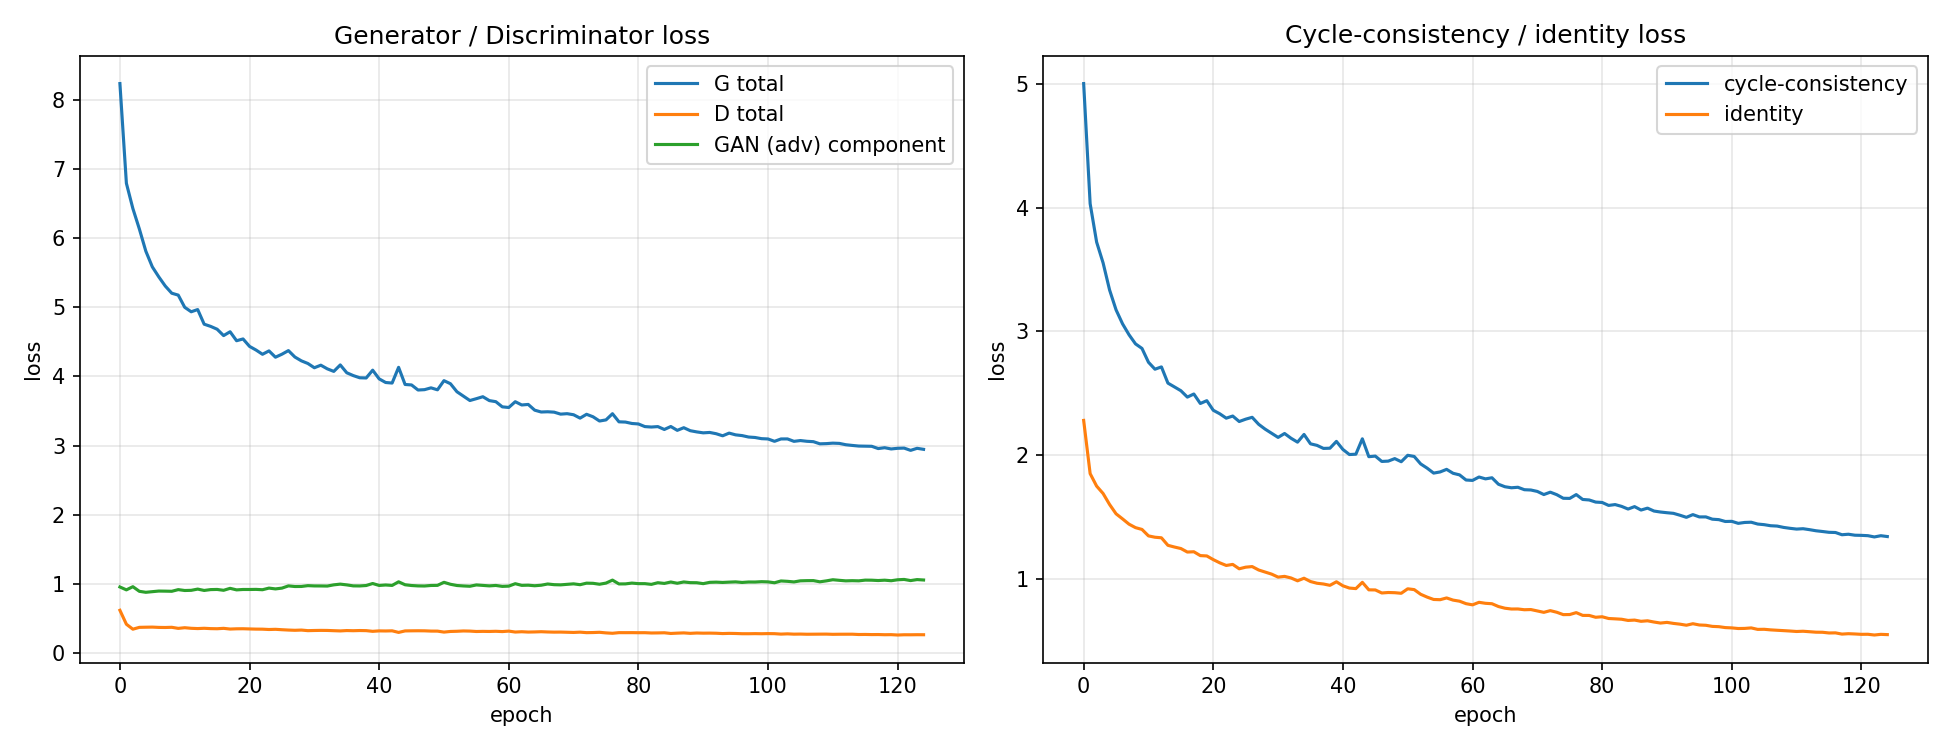

In [1]:
from IPython.display import Image
Image('../outputs/loss_curves.png')

### Checkpoint scores (TA method, last 30 epochs, raw and EMA weights)

In [1]:
print(open('../outputs/checkpoint_scores.csv').read())

epoch,weights,fid_b2a,mifid_b2a,fid_a2b,mifid_a2b,fid,mifid,score
95,raw,95.4962,0.3967,98.6588,0.4119,97.0775,0.4043,48.7409
95,ema,95.7458,0.3994,98.4416,0.4126,97.0937,0.406,48.7498
96,raw,95.7262,0.3991,96.9238,0.4109,96.325,0.405,48.365
96,ema,96.1368,0.4,98.79,0.4128,97.4634,0.4064,48.9349
97,raw,97.339,0.3998,100.8091,0.4145,99.074,0.4071,49.7406
97,ema,96.1474,0.4003,98.6306,0.4128,97.389,0.4066,48.8978
98,raw,95.5877,0.403,99.2831,0.413,97.4354,0.408,48.9217
98,ema,96.0023,0.4005,98.431,0.4126,97.2166,0.4065,48.8116
99,raw,94.6663,0.4014,97.5802,0.4131,96.1232,0.4072,48.2652
99,ema,94.9988,0.3991,98.1541,0.4128,96.5765,0.4059,48.4912
100,raw,94.8882,0.4014,100.3058,0.4128,97.597,0.4071,49.0021
100,ema,95.1583,0.4,98.0403,0.4129,96.5993,0.4064,48.5029
101,raw,96.3902,0.3989,98.269,0.4121,97.3296,0.4055,48.8676
101,ema,95.1754,0.4006,98.1102,0.4128,96.6428,0.4067,48.5248
102,raw,94.867,0.3999,100.1839,0.4126,97.5255,0.4063,48.9659
102,ema,95.6187,0.4007,97.8121,0.412,96.7154,0.4

## Run: `python generate.py --ckpt ../checkpoints/best.pt`
Real captured output:

In [1]:
print(open('../outputs/console_generate.log').read())

Checkpoint ../checkpoints/best.pt: ngf=64 blocks=9 upsample=nearest | epoch 110 raw  | monet->photo views: 6
pred_A2B (monet->photo): 300 images in 29.5s (10.18 img/s)
pred_B2A (photo->monet): 7038 images in 130.4s (53.98 img/s)  <-- Kaggle submission direction
Wrote ../outputs\images.zip
Wrote C:\Ritika_cuda\Data_266-Lab1\task3_gan\ritika_mukesh_neema\generation_manifest.csv
Next: python ta_score.py   (official FID / MiFID -> submission.csv)

## Run: `python evaluate_local.py` (TA script -> submission.csv)
Real captured output:

In [1]:
print(open('../outputs/console_evaluate_local.log').read())

Device: cuda

Counts (after N_EVAL cap):
Real Monet: 300  | Gen Monet (B2A): 300
Real Photo: 300  | Gen Photo (A2B): 300

 Evaluating Photo -> Monet (B2A) 

Inception activations: 100%|██████████| 10/10 [00:01<00:00,  5.89it/s]

Inception activations: 100%|██████████| 10/10 [00:01<00:00,  7.29it/s]
C:\Ritika_cuda\Data_266-Lab1\task3_gan\ritika_mukesh_neema\evaluate_local.py:107: DeprecationWarning: The `disp` argument is deprecated and will be removed in SciPy 1.18.0.
  covmean, _ = scipy.linalg.sqrtm(sigma1.dot(sigma2), disp=False)
[Photo->Monet] FID=93.892  MiFID=0.3991

 Evaluating Monet -> Photo (A2B) 

Inception activations: 100%|██████████| 10/10 [00:01<00:00,  6.16it/s]

Inception activations: 100%|██████████| 10/10 [00:01<00:00,  7.68it/s]
[Monet->Photo] FID=97.316  MiFID=0.4118
   ID        FID     MiFID
0   1  95.603722  0.405432
Wrote C:\Ritika_cuda\Data_266-Lab1\task3_gan\ritika_mukesh_neema\submission.csv | leaderboard score = -(FID + MiFID) / 2 = -48.0046

## Run: `python full_metrics.py --ckpt ../checkpoints/best.pt`
Real captured output:

In [1]:
print(open('../outputs/console_full_metrics.log').read())

C:\Ritika_cuda\Data_266-Lab1\task3_gan\ritika_mukesh_neema\src\full_metrics.py:79: DeprecationWarning: The `disp` argument is deprecated and will be removed in SciPy 1.18.0.
  covmean = linalg.sqrtm(sigma1.dot(sigma2), disp=False)
C:\Ritika_cuda\venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Ritika_cuda\venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Loading Inception v3 feature extractor (downloads pretrained weights on first run)...
Extracting features: real monet (A) / real photo (B) / fake monet 

### submission.csv (Kaggle upload; leaderboard = -(FID + MiFID) / 2)

In [1]:
print(open('../submission.csv').read())

ID,FID,MiFID
1,95.60372227321069,0.4054316282272339


## Visual check: photo | photo->Monet | Monet | Monet->photo

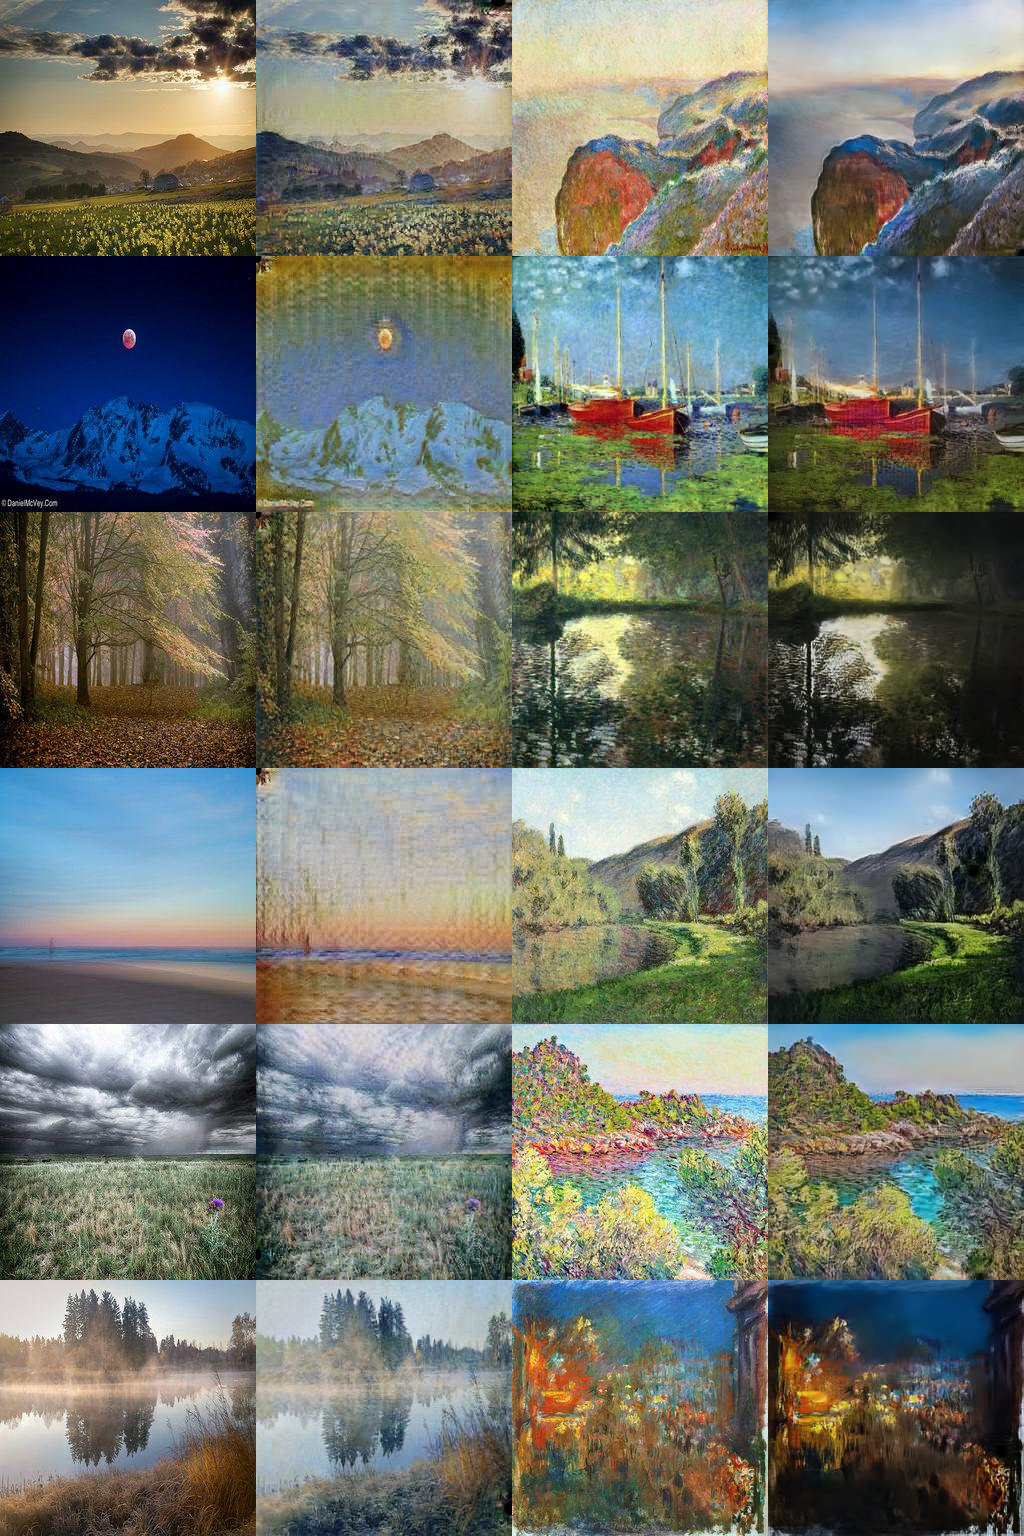

In [1]:
from IPython.display import Image
Image('../outputs/sample_grid.png')